In [11]:
import numpy as np
import matplotlib.pyplot as plt

# GridWorld Environment

In [12]:
class GridWorld:
    """
    H×W gridworld with deterministic dynamics.

    States   : integers s = i*W + j
    Actions  : 0=N  1=S  2=E  3=W
    Terminals: absorbing, zero reward
    Teleport : dict {s: (s', r)}  —  landing on s gives r and jumps to s'
    """

    def __init__(self, H=4, W=4, terminal_states=None, step_reward=-1.0, teleport=None, seed=None):
        self.height, self.width = H, W
        self.n_states = H * W
        self.n_actions = 4
        self.actions = {0: (-1, 0), 1: (1, 0), 2: (0, 1), 3: (0, -1)}   # N S E W
        self.arrows = {0: "↑",     1: "↓",    2: "→",    3: "←"}
        self.step_reward = step_reward
        self.terminal_states = set(terminal_states or [])
        self.teleport = teleport or {}
        self.rng = np.random.default_rng(seed)
        self.build_transitions()

    def row_and_col_to_state(self, row, col):
        return row * self.width + col

    def state_to_row_col(self, state):
        return divmod(state, self.width)

    def build_transitions(self):
        # Build a deterministic transition table for every state-action pair
        self.P = {}
        for s in range (self.n_states):
            for a in range (self.n_actions):
                # Terminal states are absorbing and give zero reward
                if s in self.terminal_states:
                    self.P[s, a] = (s, 0.0)
                    continue
                
                # Convert the current state index into grid coordinates
                i, j = self.state_to_row_col(s)

                # Apply the chosen action's movement delta
                di, dj = self.actions[a]
                ni, nj = i + di, j + dj

                # If the move goes off the grid, stay in the same state
                if ni < 0 or ni >= self.height or nj < 0 or nj >= self.width:
                    next_state = s
                else:
                    next_state = self.row_and_col_to_state(ni, nj)

                # If the destination is a teleport tile, jmup and override the reward
                if next_state in self.teleport:
                    next_state, reward = self.teleport[next_state]
                else:
                    # Otherwise, use the default step reward
                    reward = self.step_reward

                self.P[s, a] = (next_state, reward)

        # TODO (Task 1):
        # For every state s in range(self.n_states) and every action a in range(self.n_actions):
        #   - If s is a terminal state: self.P[s, a] = (s, 0.0)  (absorbing, no reward)
        #   - Otherwise:
        #       1. Compute the candidate next cell (ni, nj) by adding the action delta to (i, j).
        #       2. If (ni, nj) is out of bounds, stay in place: next_state = s.
        #          Otherwise: next_state = self.row_and_col_to_state(ni, nj).
        #       3. If next_state is a key in self.teleport, unpack (next_state, reward) from it.
        #          Otherwise: reward = self.step_reward.
        #       4. Store self.P[s, a] = (next_state, reward).
        
        # raise NotImplementedError

    def reset(self, start_state=None):
        non_term = [s for s in range(self.n_states) if s not in self.terminal_states]
        self.state = start_state if start_state is not None else int(self.rng.choice(non_term))
        return self.state

    def step(self, action):
        """Returns (next_state, reward, done)."""
        # Look up the deterministic transition for the current state and action
        next_state, reward = self.P[self.state, action]

        # Update the environment state
        self.state = next_state

        # An episode ends when the agent reaches a terminal state
        done = next_state in self.terminal_states
        return next_state, reward, done
        # TODO (Task 2):
        # Look up self.P[self.state, action] to get (next_state, reward).
        # Update self.state to next_state.
        # Return (next_state, reward, done) where done = next_state in self.terminal_states.
        
        # raise NotImplementedError

    # ------------------------------------------------------------------ rendering (given)
    def render_base_grid(self, ax, title):
        ax.set_xlim(-0.5, self.width - 0.5)
        ax.set_ylim(self.height - 0.5, -0.5)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(title)
        for state in self.terminal_states:
            i, j = self.state_to_row_col(state)
            ax.add_patch(plt.Rectangle((j-.5, i-.5), 1, 1, fc="#d0d0d0", ec="black", lw=1.5, zorder=1))
            ax.text(j, i, "T", ha="center", va="center", fontsize=13, fontweight="bold", zorder=2)
        for x in np.arange(-.5, self.width, 1):
            ax.axvline(x, color="#cccccc", lw=0.5)
        for y in np.arange(-.5, self.height, 1):
            ax.axhline(y, color="#cccccc", lw=0.5)

    def render_values(self, V, title="$V^\\pi$", fmt="{:.1f}", ax=None):
        show = ax is None
        if ax is None:
            _, ax = plt.subplots(figsize=(self.width * 1.1, self.height * 1.1))
        grid = V.reshape(self.height, self.width)
        im = ax.imshow(grid, cmap="RdYlGn", aspect="equal", vmin=V.min(), vmax=V.max())
        plt.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
        self.render_base_grid(ax, title)
        for state in range(self.n_states):
            if state in self.terminal_states: continue
            i, j = self.state_to_row_col(state)
            ax.text(j, i, fmt.format(V[state]), ha="center", va="center", fontsize=9, zorder=2)
        if show: plt.tight_layout(); plt.show()
        return ax

# Random Policy

In [13]:
class RandomPolicy:
    """pi(a|s) = 1/4  for all a, s."""
    def __init__(self, n_actions=4, seed=None):
        self.n_actions = n_actions
        self.rng = np.random.default_rng(seed)

    def act(self, state):
        # Sample uniformly from all actions (state-independent)
        return int(self.rng.choice(self.n_actions))
        
        # TODO (Task 3): return a single integer action sampled uniformly from {0,...,n_actions-1}.
        
        # raise NotImplementedError

    def prob(self, state):
        #Return uniform probability vector over all actions (state-independent)
        return np.full(self.n_actions, 1.0 / self.n_actions)
        
        # TODO (Task 3): return a numpy array of length n_actions with uniform probabilities.
        
        # raise NotImplementedError

# Exact Policy Evaluation via Matrix Inversion

In [14]:
def policy_evaluation_exact(env, policy, gamma=1.0):
    """
    Solve  (I - gamma * P_pi) V = R_pi  exactly.
    Returns V of shape (n_states,).
    """
    n = env.n_states
    P_pi = np.zeros((n, n))
    R_pi = np.zeros(n)

    # Building P_pi and R_pi for the given policy
    for s in range(n):
        if s in env.terminal_states:
            continue # This leaves the terminal rows as zero

        pi = policy.prob(s) # This is the shape (n_actions)
        for a in range(env.n_actions):
            s2, r = env.P[s, a]
            P_pi[s, s2] += pi[a]
            R_pi[s] += pi [a] * r
    # TODO (Task 4a):
    # For each non-terminal state s:
    #     pi = policy.prob(s)       # shape (n_actions,)
    #     for each action a:
    #         s2, r = env.P[s, a]
    #         P_pi[s, s2] += ...
    #         R_pi[s] += ...
    # Leave terminal rows as zero — do NOT set P_pi[t,t]=1.
    # This way (I - gamma*P_pi)[t,:] = e_t and b[t]=0, so V[t]=0 for any gamma.

    I = np.eye(n)
    A = I - gamma * P_pi
    V = np.linalg.solve(A, R_pi)
    return V
    # TODO (Task 4b):
    # Build A = I - gamma * P_pi and solve A @ V = R_pi with np.linalg.solve.
    
    # raise NotImplementedError

# Experiment: compare to S&B Example 4.1

Your result:
[[  0. -14. -20. -22.]
 [-14. -18. -20. -20.]
 [-20. -20. -18. -14.]
 [-22. -20. -14.   0.]]

S&B Example 4.1:
[[  0. -14. -20. -22.]
 [-14. -18. -20. -20.]
 [-20. -20. -18. -14.]
 [-22. -20. -14.   0.]]

Max absolute error: 7.11e-15


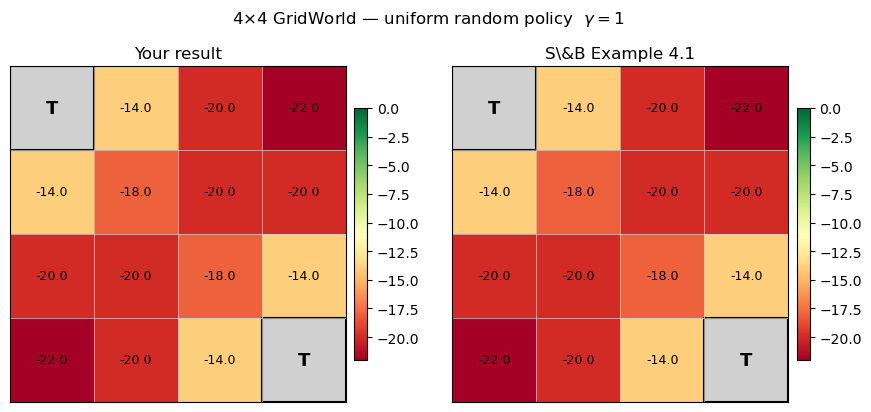

In [15]:
# S&B Example 4.1: uniform random policy, 4x4 grid, terminal corners, r=-1, gamma=1
V_sb = np.array([
     0, -14, -20, -22,
   -14, -18, -20, -20,
   -20, -20, -18, -14,
   -22, -20, -14,   0,
], dtype=float)

env = GridWorld(H=4, W=4, terminal_states=[0, 15], step_reward=-1.0)
pi = RandomPolicy(seed=0)

V = policy_evaluation_exact(env, pi, gamma=1.0)

print("Your result:")
print(V.reshape(4, 4).round(1))
print()
print("S&B Example 4.1:")
print(V_sb.reshape(4, 4))
print()
print(f"Max absolute error: {np.max(np.abs(V - V_sb)):.2e}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
env.render_values(V, title="Your result", ax=axes[0])
env.render_values(V_sb, title="S\\&B Example 4.1", ax=axes[1])
plt.suptitle("4×4 GridWorld — uniform random policy  $\\gamma=1$", y=1.02)
plt.tight_layout()
plt.show()